In [1]:
input_tce_csv_file = "/pdo/astronet-data/data/properties/tces-sector87.csv"
# tess_data_dir = "/pdo/astronet-data/data/fits/sector-87/"
tess_data_dir = '/pdo/users/pablomer/mnt/tess/sec85-85_fit_files_2'

# tess_data_dir = '/pdo/astronet-data/data/fits/sector-87-p-v2'

# tess_data_dir = '/pdo/users/pablomer/mnt/tess/debug-h5fits'
# astro_id_to_inspect = 30081274102
astro_id_to_inspect = 33996120001
# astro_id_to_inspect = 34514346003

In [2]:
import os
os.chdir('/pdo/users/pablomer/Astronet-Triage')
import sys
sys.path.insert(0, "/pdo/users/pablomer/Astronet-Triage")


In [3]:
from typing import Optional
import pandas as pd
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt

tce_table = pd.read_csv(input_tce_csv_file, header=0, low_memory=False)
print(f'Loaded {len(tce_table)}, downsampling to 1 id {astro_id_to_inspect}')
tce = tce_table[tce_table["Astro ID"] == astro_id_to_inspect].iloc[0]
print(tce.to_string())

def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        tess_data_dir,
        aperture_key_map[aperture],
        # tess_data_dir+'/astronet_hlsp_qlp_tess_ffi-s0087-0000000300812741_tess_v01_llc.fits',
        tess_data_dir +'/astronet_hlsp_qlp_tess_ffi-s0087-0000000' + str(astro_id_to_inspect)[:-2] + '_tess_v01_llc.fits',
        tce.MinT,
        tce.MaxT,
    )

Loaded 4824, downsampling to 1 id 33996120001
TIC ID                                              339961200
SMass                                                    0.92
SRad                                                  0.88283
Tmag                                                   9.7333
planetno                                                    1
Epoc                                              1386.069612
Per                                                  3.212667
Depth                                              453.204966
Dur                                                  0.045768
SRadEst                                                   NaN
Astro ID                                          33996120001
File        /pdo/astronet-data/data/fits/sector-87/astrone...


In [4]:
# from astronet.preprocess import preprocess
import astronet.preprocess.preprocess as preprocess
print(dir(preprocess))
print(hasattr(preprocess, 'read_and_process_light_curve'))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'detrend_and_filter', 'filter_outliers', 'find_secondary', 'generate_view', 'get_spline_mask', 'global_view', 'keplersplinev2', 'local_view', 'mask_transit', 'median_filter2', 'np', 'os', 'phase_fold_and_sort_light_curve', 'read_and_process_light_curve', 'sample_segments', 'sample_segments_view', 'secondary_view', 'tess_io', 'tr_mask_view', 'util']
True


In [5]:
# from astronet.preprocess import preprocess
import astronet.preprocess.preprocess as preprocess
print(dir(preprocess))
print(hasattr(preprocess, 'read_and_process_light_curve'))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'detrend_and_filter', 'filter_outliers', 'find_secondary', 'generate_view', 'get_spline_mask', 'global_view', 'keplersplinev2', 'local_view', 'mask_transit', 'median_filter2', 'np', 'os', 'phase_fold_and_sort_light_curve', 'read_and_process_light_curve', 'sample_segments', 'sample_segments_view', 'secondary_view', 'tess_io', 'tr_mask_view', 'util']
True


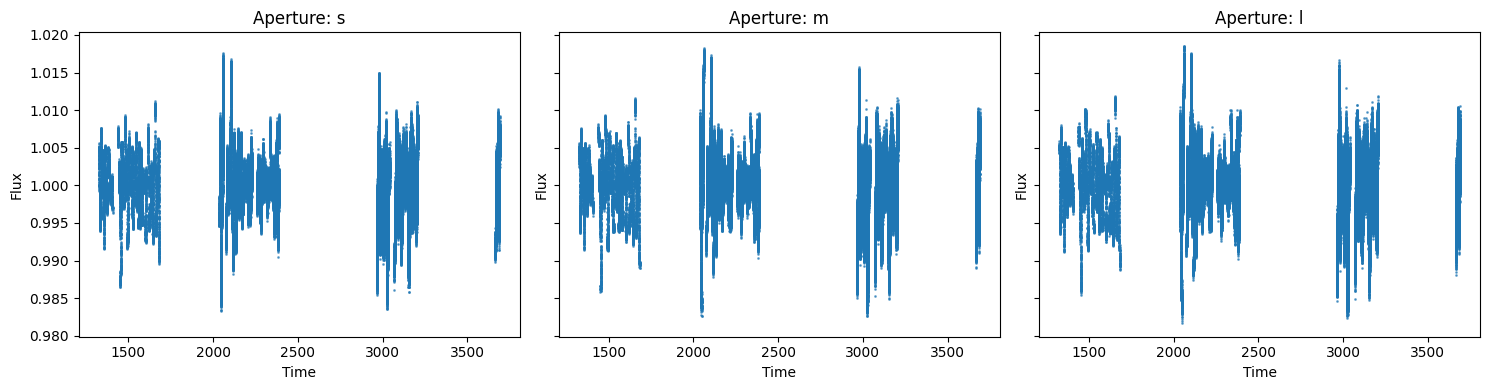

In [6]:
# Process TCE function call

# Step 1: Get aperturues
time, flux = get_lightcurve(tce['Astro ID'])
apertures = {
    's': get_lightcurve(tce['Astro ID'], aperture='s'),
    'm': get_lightcurve(tce['Astro ID'], aperture='m'),
    'l': get_lightcurve(tce['Astro ID'], aperture='l'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (label, (t, f)) in zip(axes, apertures.items()):
    ax.plot(t, f, '.', markersize=2, alpha=0.6)
    ax.set_title(f"Aperture: {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Flux")
    # ax.set_xlim(1320,1350)

plt.tight_layout()
plt.show()

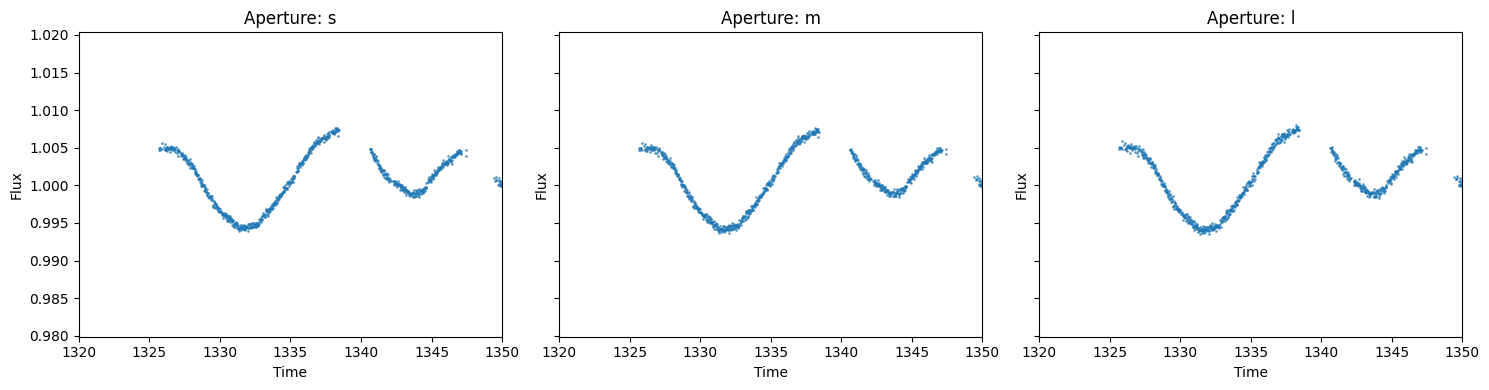

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (label, (t, f)) in zip(axes, apertures.items()):
    ax.plot(t, f, '.', markersize=2, alpha=0.6)
    ax.set_title(f"Aperture: {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Flux")
    ax.set_xlim(1320,1350)

plt.tight_layout()
plt.show()

In [19]:
time

array([1325.65692466, 1325.6777576 , 1325.71942348, ..., 3689.73521755,
       3689.7375324 , 3689.74679182])

Text(0, 0.5, 'time')

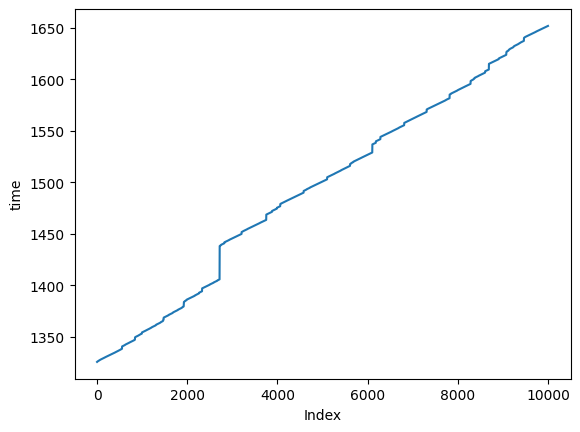

In [8]:
plt.plot(time[:10000])
plt.xlabel('Index')
plt.ylabel('time')

In [21]:
int(time.shape[0])//10

13600

Using: /pdo/users/pablomer/Astronet-Triage/light_curve_util/median_filter2.py
DEBUG enabled? None
Has debug print? True


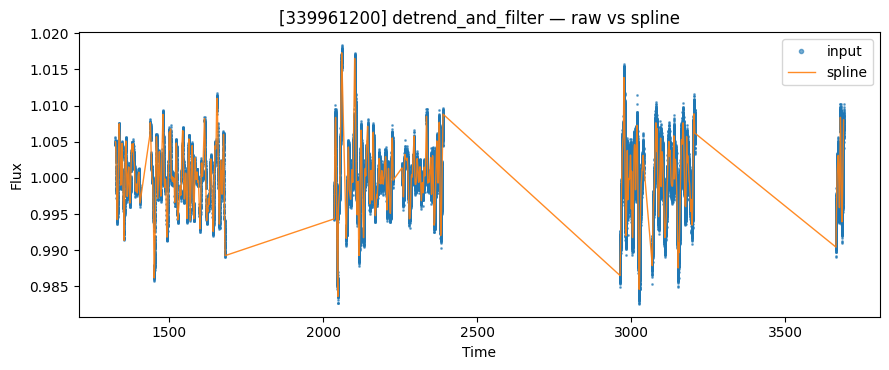

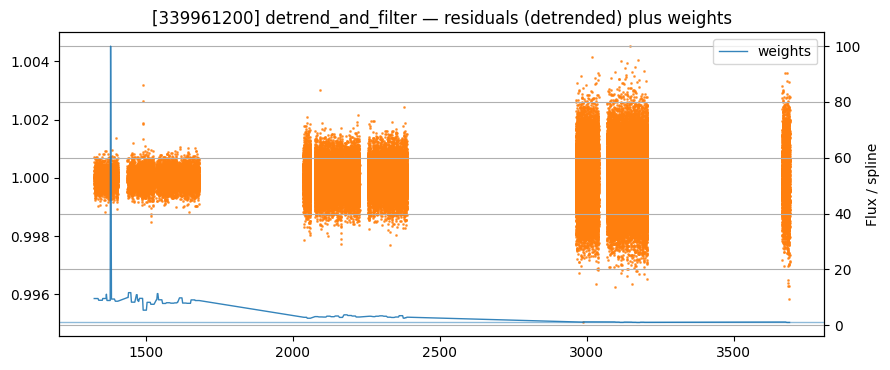

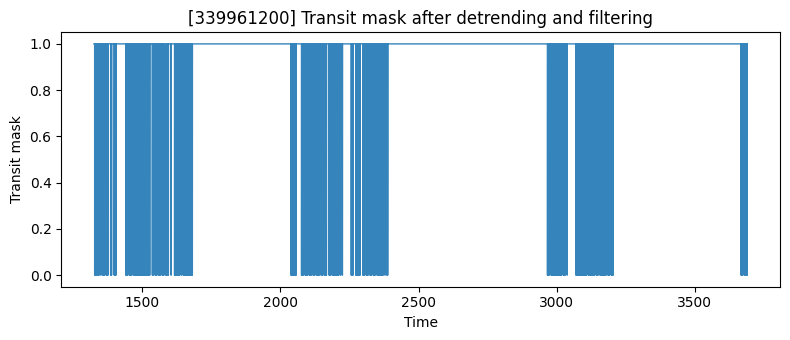

epoc: 1386.06961162385
duration: 0.0457676673338244
period: 3.212666888242244
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_flux: [0.99999257 0.99974441 0.99978479 ... 0.99980246 0.99916226 1.00141487]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]


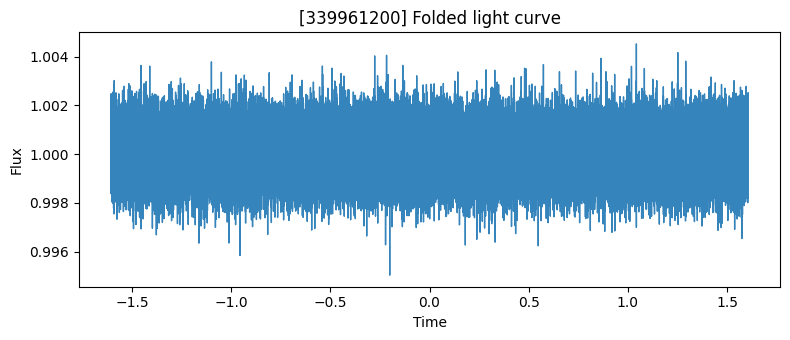

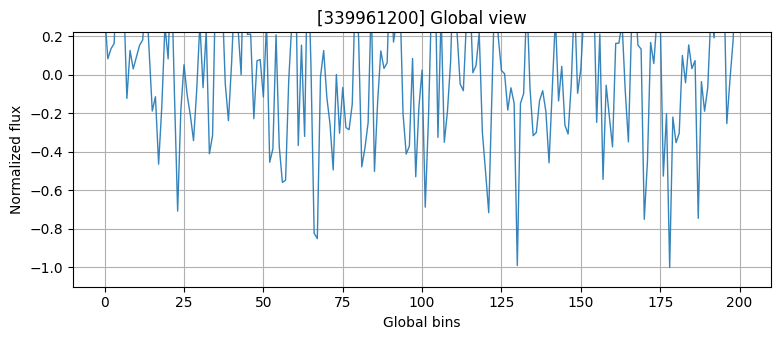

View values: [ 3.20188633e-01  8.27699871e-02  1.34810902e-01  1.62042152e-01
  6.42682853e-01  4.64167277e-01  4.10438826e-01 -1.22968642e-01
  1.25990696e-01  3.04481380e-02  9.14814091e-02  1.52565063e-01
  1.80897509e-01  4.48699544e-01  1.30869364e-01 -1.88468120e-01
 -1.14064664e-01 -4.63973045e-01 -1.67563041e-01  2.53888235e-01
  8.23265127e-02  5.56091373e-01 -1.06456701e-01 -7.07560882e-01
 -1.85465969e-01  5.17860852e-02 -1.05349914e-01 -2.10066300e-01
 -3.42083912e-01 -8.08534764e-02  2.66793888e-01 -6.71286935e-02
  2.26738165e-01 -4.10260563e-01 -3.14416330e-01  5.08015156e-01
  3.03692963e-01  4.15538926e-01 -4.66232661e-02 -2.38136434e-01
  6.22172953e-02  4.54806770e-01  2.48097178e-01  0.00000000e+00
  7.69580208e-01  2.08376673e-01  2.11233618e-01 -2.27971795e-01
  7.24202157e-02  7.87374085e-02 -1.15412012e-01  2.68200954e-01
 -4.54037449e-01 -3.84333297e-01  2.07273367e-01 -3.70883120e-01
 -5.58906768e-01 -5.47118354e-01 -2.52844379e-02  2.77790983e-01
  7.34679837

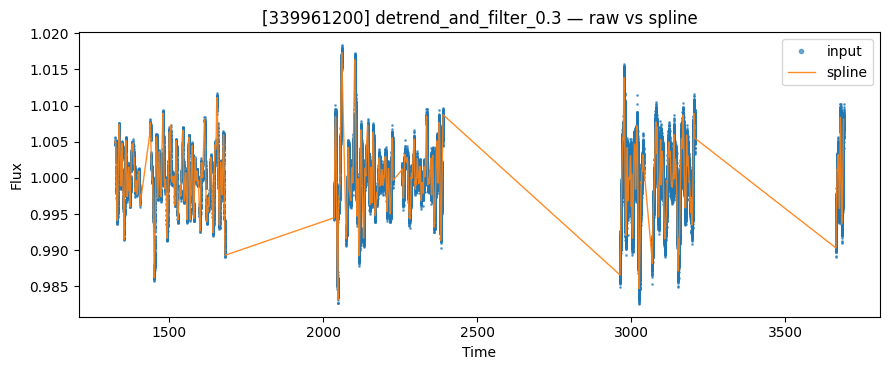

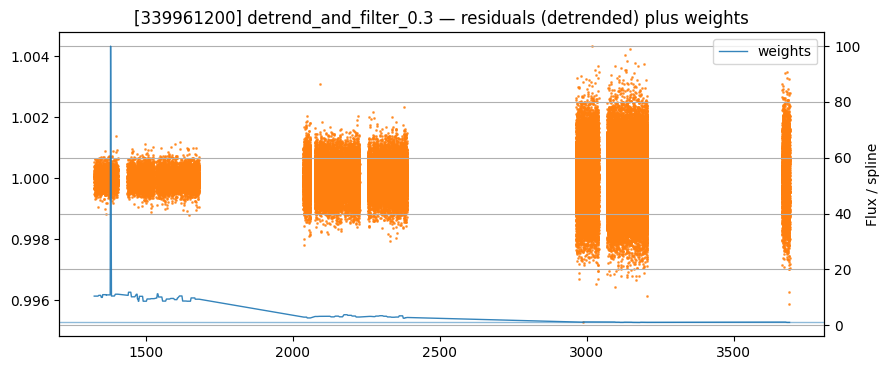

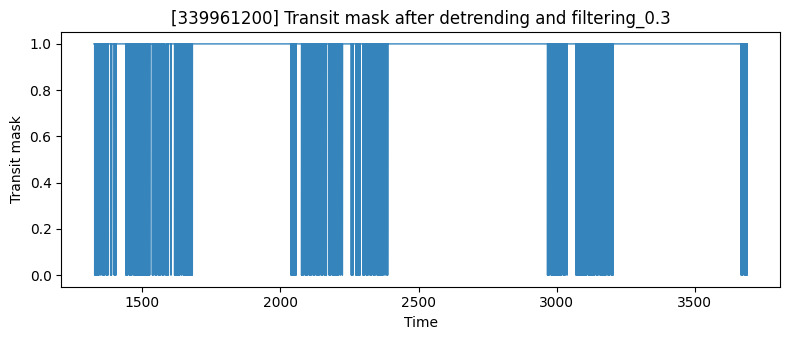

epoc: 1386.06961162385
duration: 0.0457676673338244
period: 3.212666888242244
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_flux: [1.00015694 0.99988517 0.99986804 ... 0.99973899 0.99909646 1.00133912]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]


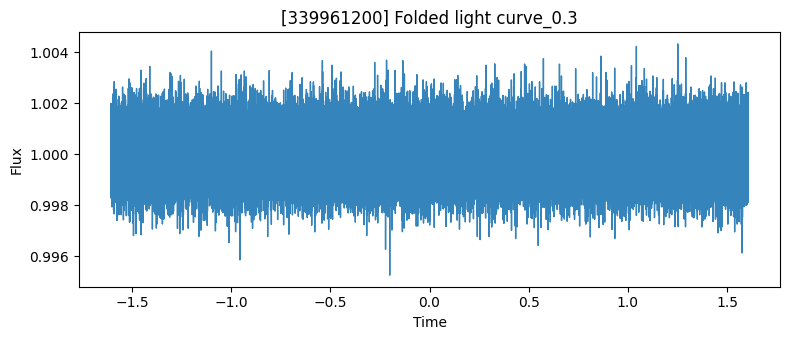

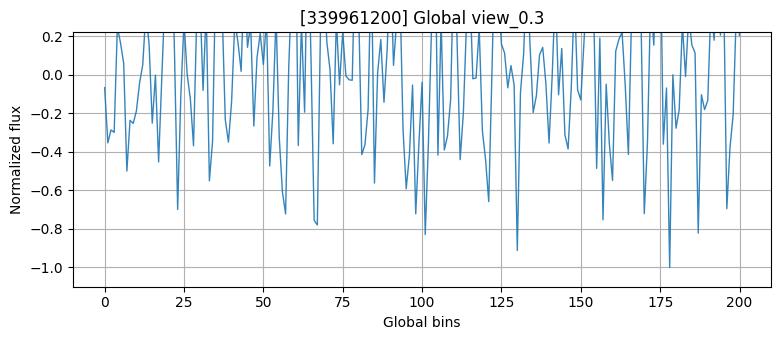

View values: [-0.06687885 -0.35360267 -0.28656937 -0.29919742  0.24856443  0.16518584
  0.05850103 -0.49968942 -0.23681336 -0.25246082 -0.18817109 -0.04335206
  0.05155842  0.32748419  0.15747896 -0.25106774 -0.00240356 -0.45245252
 -0.01579427  0.41553949  0.22960179  0.80067502  0.11878724 -0.69913744
 -0.10694114  0.27590334  0.00174344 -0.12630856 -0.36861395  0.29286863
  0.41718501 -0.08125984  0.33747474 -0.55090067 -0.34345832  0.54341559
  0.27704872  0.34229697 -0.23244187 -0.3498915  -0.13862469  0.27476083
  0.16903922  0.01760545  0.54026266  0.14223709  0.26255547 -0.26664566
  0.08864564  0.21414042  0.05323057  0.29546875 -0.47386752 -0.18736139
  0.30949824 -0.32277706 -0.60649957 -0.7223654   0.04324425  0.48276811
  0.96937341 -0.36732553  0.26620631 -0.19429966  0.83670081  0.0912643
 -0.75547955 -0.77945433  0.24681764  0.52180328  0.16930521  0.02458931
 -0.35842636  0.28473549 -0.05218692  0.22152519 -0.0059112  -0.02623368
 -0.02857951  0.72065548  0.35248724 -0

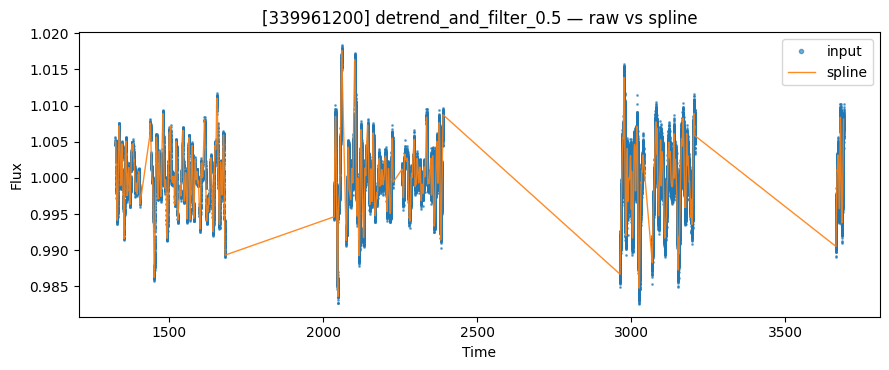

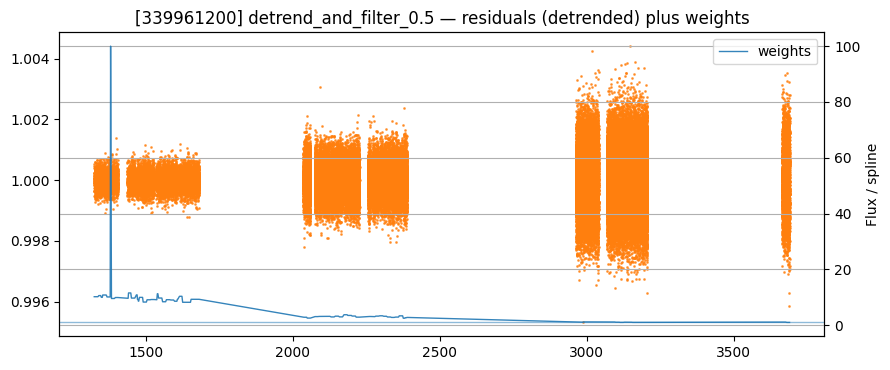

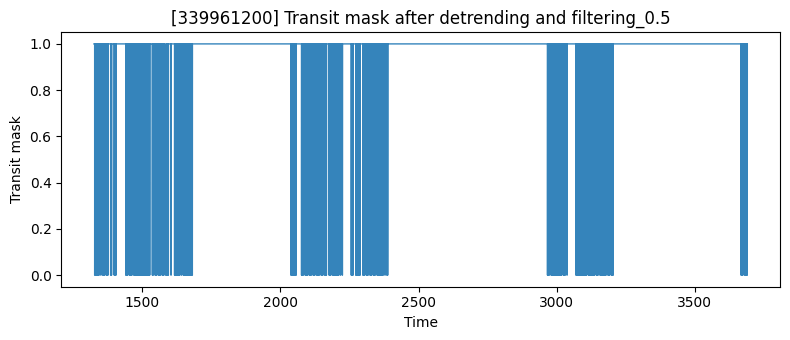

epoc: 1386.06961162385
duration: 0.0457676673338244
period: 3.212666888242244
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_flux: [1.00023101 0.99990896 0.99982731 ... 0.99972588 0.99908246 1.00132123]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]


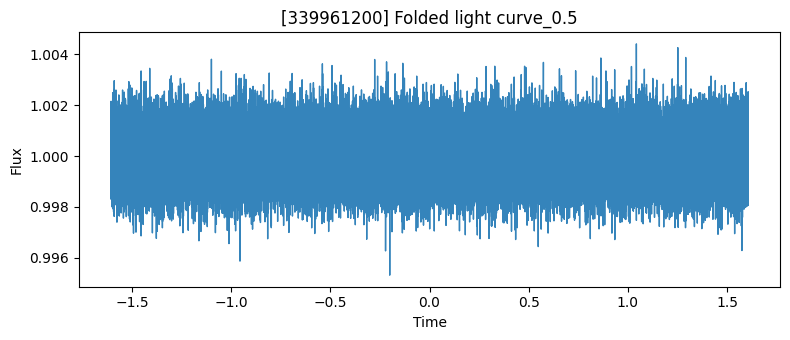

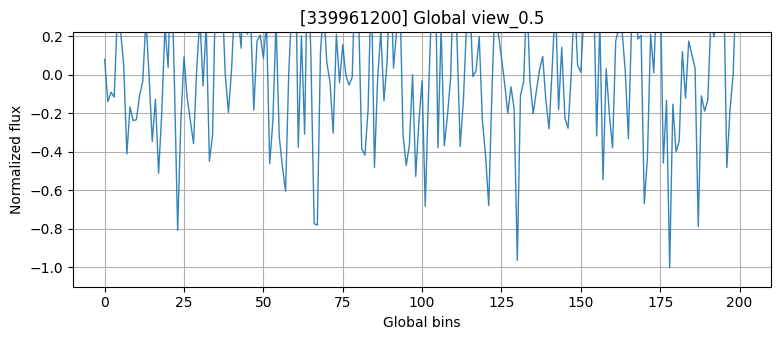

View values: [ 8.01587919e-02 -1.39312967e-01 -9.09901743e-02 -1.15941982e-01
  3.07576888e-01  2.29411106e-01  4.88505418e-02 -4.11072991e-01
 -1.66659269e-01 -2.38060243e-01 -2.33152498e-01 -1.08446389e-01
 -3.43873843e-02  2.89684950e-01 -6.32264518e-03 -3.46488708e-01
 -1.27632909e-01 -5.11746845e-01 -1.95591257e-01  2.51276815e-01
  3.78528152e-02  6.02020317e-01 -5.88712341e-02 -8.07050201e-01
 -2.47176447e-01  9.25005531e-02 -1.19491158e-01 -2.37984819e-01
 -3.57386696e-01  2.70873170e-02  2.93854870e-01 -5.74514391e-02
  2.63907788e-01 -4.48775329e-01 -3.13453559e-01  5.00020907e-01
  2.70956183e-01  4.18351882e-01  3.31873789e-04 -1.95274508e-01
  3.08913121e-02  3.98512739e-01  3.15963739e-01  1.37625635e-01
  6.41571369e-01  2.10452163e-01  2.91318420e-01 -1.83706148e-01
  1.73373473e-01  2.06481401e-01  8.62645964e-02  2.66511739e-01
 -4.60785086e-01 -2.38767813e-01  2.76472153e-01 -3.18653855e-01
 -4.78071978e-01 -6.04494416e-01  8.72081836e-03  3.68215965e-01
  7.48968636

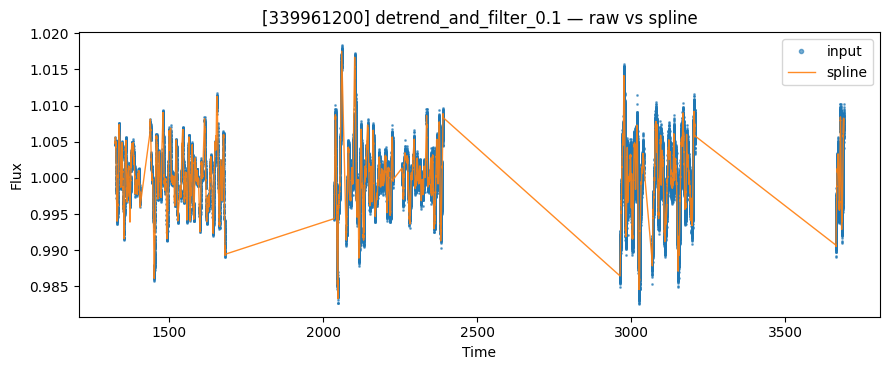

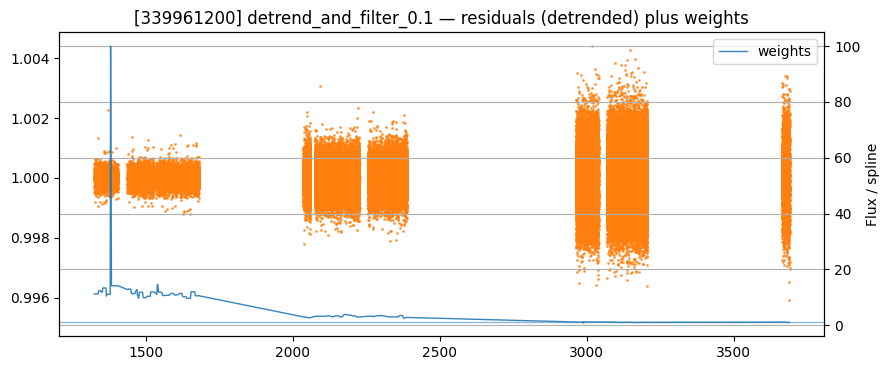

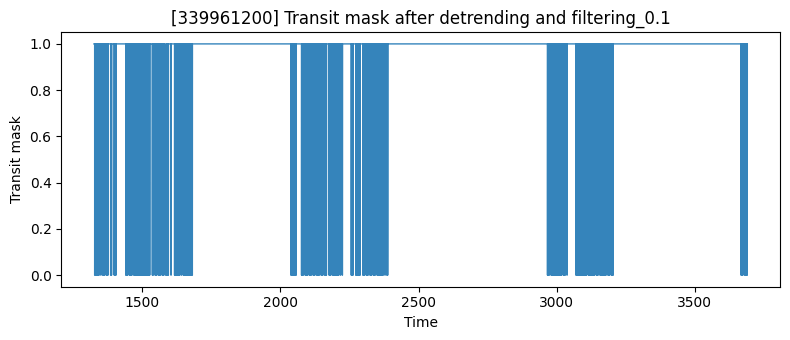

epoc: 1386.06961162385
duration: 0.0457676673338244
period: 3.212666888242244
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_flux: [0.99998601 1.00002835 0.99998388 ... 0.99959748 0.99895707 1.00122216]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]


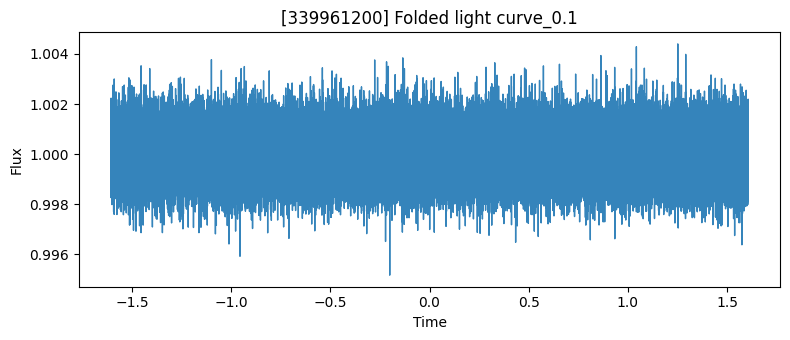

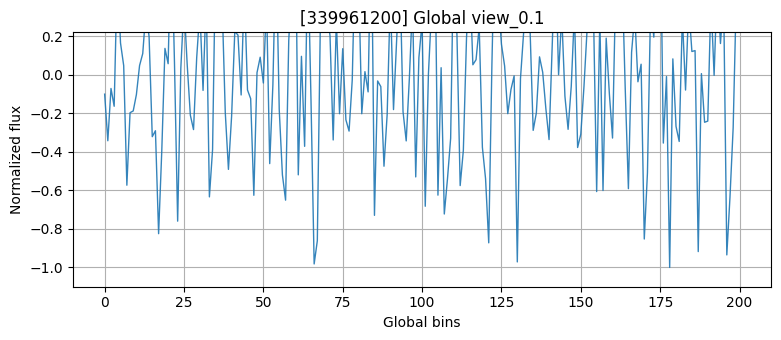

View values: [-0.10083407 -0.34258408 -0.07130687 -0.16364737  0.54850967  0.16427069
  0.0474207  -0.5732653  -0.19711554 -0.18794485 -0.10307882  0.04754931
  0.10968927  0.33201222  0.19782857 -0.32143914 -0.2906286  -0.82475254
 -0.39425345  0.13671983  0.05718473  0.75875285  0.06125043 -0.75979594
  0.03446496  0.36933121  0.0545855  -0.2101466  -0.28463876  0.08894671
  0.33504923 -0.0813382   0.41297233 -0.63384377 -0.38825141  0.67597912
  0.39522398  0.37847396 -0.19548473 -0.49113016 -0.21413836  0.22472159
  0.20584666 -0.1050193   0.45828258 -0.07919655 -0.12407626 -0.62549836
  0.01093295  0.09093744 -0.0428641   0.38334758 -0.46120803 -0.05248339
  0.68030445 -0.18113147 -0.51937327 -0.65087583  0.17883606  0.48337836
  0.96567825 -0.51945803  0.09542428 -0.37153029  0.63986446 -0.12566175
 -0.98182635 -0.86139943  0.32764948  0.72908382  0.3494259   0.2008602
 -0.33850239  0.28355135 -0.2023078   0.13505958 -0.23389049 -0.29246005
 -0.02743864  0.68503858  0.51395256 -0

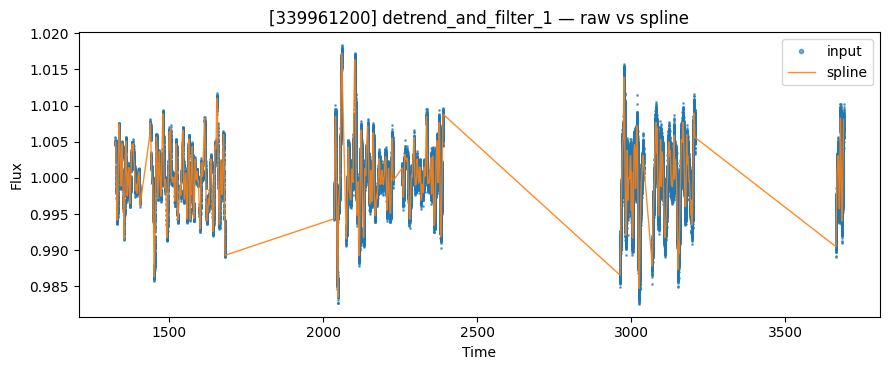

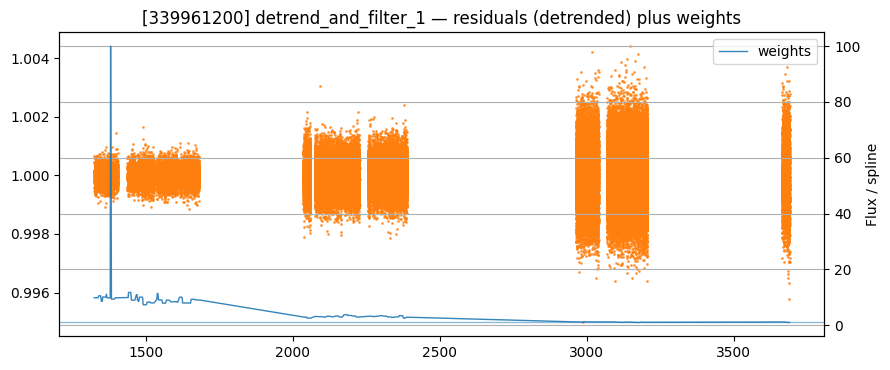

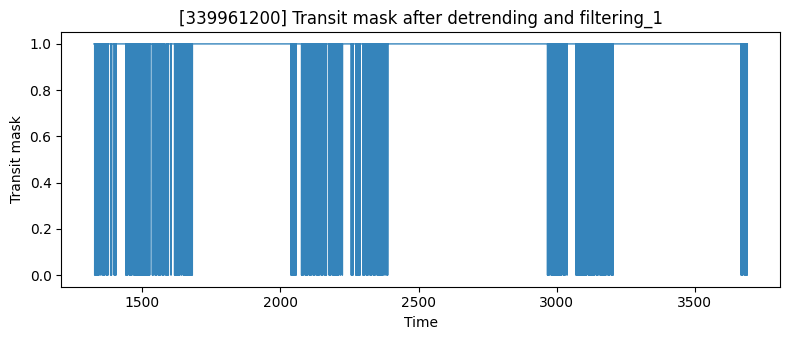

epoc: 1386.06961162385
duration: 0.0457676673338244
period: 3.212666888242244
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_flux: [1.00009899 0.999831   0.99983567 ... 0.99974103 0.99909922 1.00134489]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]


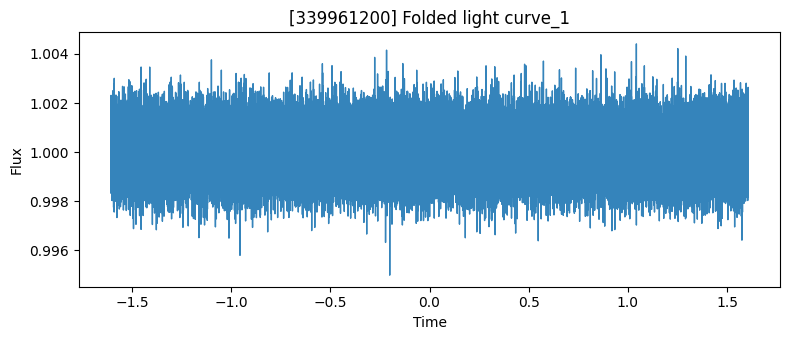

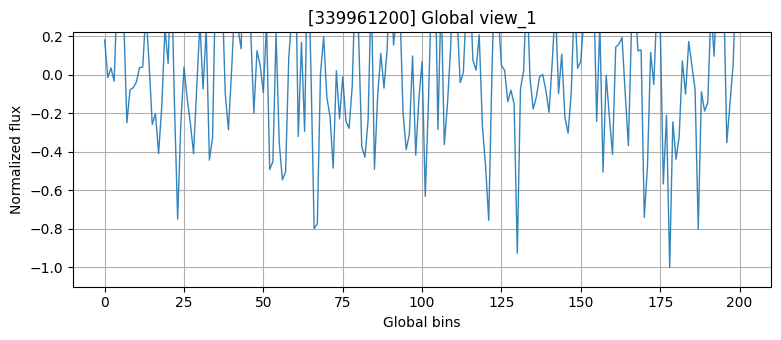

View values: [ 0.1805894  -0.015357    0.0351466  -0.03356676  0.44620354  0.33357479
  0.29841978 -0.24942419 -0.07730285 -0.06750485 -0.03792381  0.03701955
  0.03974754  0.33061676  0.0572663  -0.2575997  -0.20168256 -0.40847414
 -0.16201744  0.24073577  0.0579863   0.56345783 -0.15542555 -0.74890242
 -0.25302518  0.03971471 -0.12452066 -0.25112188 -0.40960946 -0.07515352
  0.26839656 -0.07457819  0.23960051 -0.44336526 -0.32367622  0.55057796
  0.26607024  0.43838228 -0.09908987 -0.28564552  0.02446987  0.37514534
  0.2406521   0.13497083  0.75990198  0.24966114  0.24101585 -0.19988862
  0.12463456  0.04748081 -0.09187072  0.26600136 -0.49209523 -0.45088404
  0.21372646 -0.35179922 -0.54548531 -0.50367676  0.08680948  0.31647409
  0.73667066 -0.31995794  0.16772996 -0.29375559  0.69283057  0.01665374
 -0.79892487 -0.77281949  0.00770296  0.19630906 -0.11715419 -0.21699024
 -0.48430702  0.02076771 -0.22885225 -0.01120815 -0.23949329 -0.27814114
 -0.05951952  0.51473471  0.21120303 -

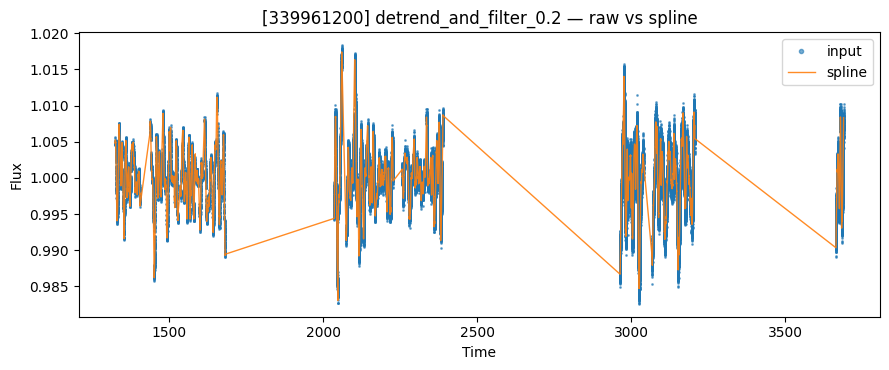

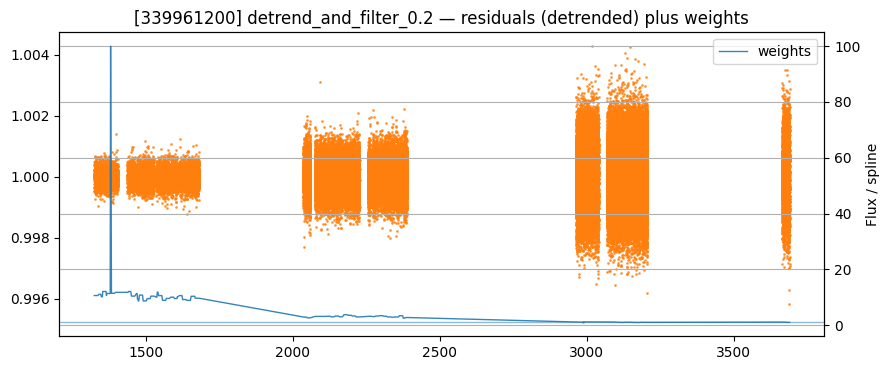

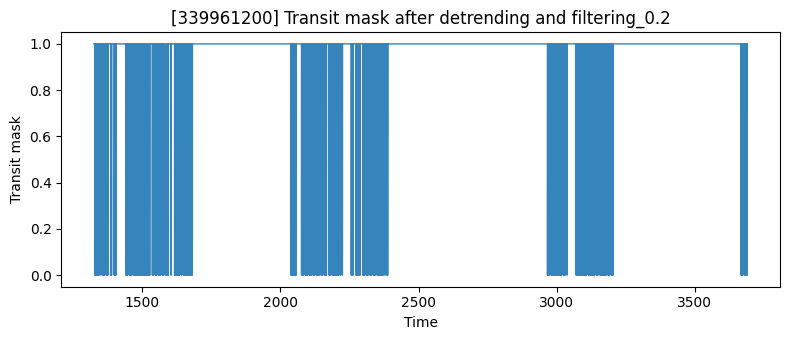

epoc: 1386.06961162385
duration: 0.0457676673338244
period: 3.212666888242244
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_flux: [1.00005497 0.99990773 0.99999187 ... 0.99958924 0.99893231 1.00111115]
transit_mask: [ True  True  True ...  True  True  True]
time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
detrended_time: [1325.65692466 1325.6777576  1325.71942348 ... 3689.73521755 3689.7375324
 3689.74679182]
flux: [1.0049547  1.00469828 1.00472677 ... 1.00776899 1.00713456 1.00944901]


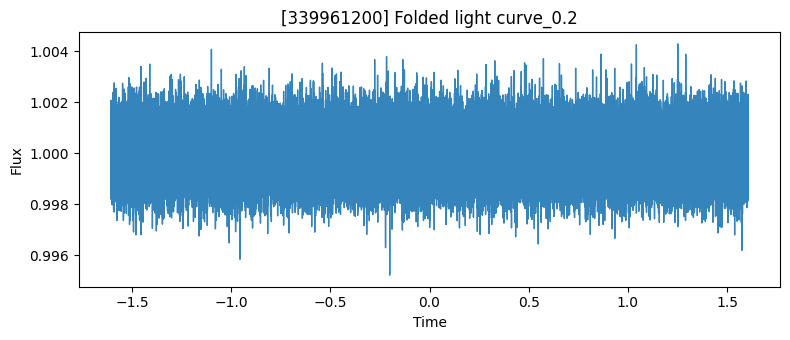

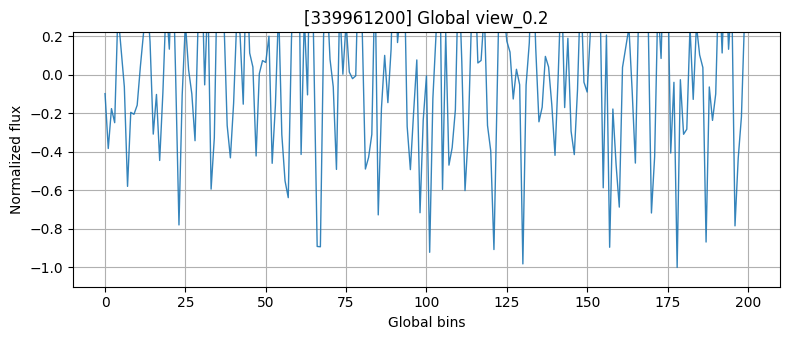

View values: [-0.09818281 -0.38282423 -0.17581674 -0.24880995  0.32495069  0.12948973
 -0.06216826 -0.5792624  -0.19511937 -0.20529837 -0.15799282  0.04374721
  0.22077614  0.41788954  0.17150776 -0.30814023 -0.10232215 -0.44484226
 -0.09162611  0.37136271  0.13265686  0.65905283 -0.03162635 -0.77939728
 -0.10706375  0.27002631  0.0250521  -0.09913008 -0.34232135  0.30429585
  0.60866902 -0.05255602  0.41705275 -0.59353207 -0.32695007  0.60594964
  0.30241831  0.28358355 -0.26343775 -0.43129285 -0.14855461  0.29721021
  0.21089756 -0.1527466   0.58685752  0.11261684  0.04012143 -0.42168026
  0.00543125  0.07337062  0.06397294  0.19987668 -0.45963204 -0.15975273
  0.34846081 -0.3104186  -0.55052494 -0.63779683  0.18242035  0.63385273
  1.14462507 -0.41370308  0.30005825 -0.10445809  0.9578767   0.06528717
 -0.89101104 -0.89269242  0.20717769  0.4362912   0.07994294 -0.06233652
 -0.49124198  0.36909777  0.00273681  0.2720276   0.01361778 -0.02033641
 -0.00576902  0.67051676  0.24406235 -

{'_none': array([582, 317, 523, ..., 571, 234, 308]),
 '_0.3': array([582, 317, 523, ..., 571, 234, 308]),
 '_0.5': array([582, 317, 523, ..., 571, 234, 308]),
 '_0.1': array([582, 317, 523, ..., 571, 234, 308]),
 '_1': array([582, 317, 523, ..., 571, 234, 308]),
 '_0.2': array([582, 317, 523, ..., 571, 234, 308])}

In [9]:
# Step 2: Generate standard views
from astronet.preprocess.preprocess import filter_outliers, get_spline_mask
from light_curve_util import keplersplinev2
from light_curve_util import median_filter2

import os, importlib, inspect
# os.environ["ASTRONET_DEBUG_BINNING"] = "1"

import light_curve_util.median_filter2 as mf2
importlib.reload(mf2)  # pick up code + env var

print("Using:", mf2.__file__)
print("DEBUG enabled?", os.getenv("ASTRONET_DEBUG_BINNING"))

# Sanity: confirm the debug print exists in this loaded function
src = inspect.getsource(mf2.new_binning)
print("Has debug print?", "[new_binning DEBUG]" in src)

def split_and_calculate_weights(time, flux, gap_width=0.75):
    """Split the time and flux whenever there is a gap in the time array.
    For each segment, calculate the scatter of the flux values and return
    an array of weights where the higher scatter values have lower weights.

    Args:
        time: 1D array of time values
        flux: 1D array of flux values
        period: The period of the event (in days)
        num_bins: The number of intervals to divide the time axis into
        t_min: The inclusive leftmost value to consider on the time axis
        t_max: The exclusive rightmost value to consider on the time axis
        gap_width: Minimum gap size (in time units) for a split

    Returns:
        weights: Array of weights for each data point
    """
    import numpy as np
    from light_curve_util.keplersplinev2 import split

    # # Split the data into segments based on gaps
    split_times, split_fluxes = split(time, flux, gap_width)
    #instead, split every 10 points
    # split_times = []
    # split_fluxes = []
    # for i in range(0, len(time), 500):
    #     split_times.append(time[i:i+500])
    #     split_fluxes.append(flux[i:i+500])

    # Initialize weights array
    weights = np.ones(len(time))

    # Calculate scatter for each segment
    segment_scatters = []
    for seg_flux in split_fluxes:
        if len(seg_flux) > 1:
            segment_scatters.append(np.std(seg_flux))
        else:
            segment_scatters.append(0.0)  # Single points get scatter 0

    # Calculate weights based on inverse scatter
    if len(segment_scatters) > 1 and np.max(segment_scatters) > 0:
        # Normalize scatters to [0, 1] range
        max_scatter = np.max(segment_scatters)
        normalized_scatters = np.array(segment_scatters) / max_scatter

        # Weight is inversely proportional to normalized scatter
        # Add small value to avoid division by zero
        segment_weights = 1.0 / (normalized_scatters**2 + 1e-2)

        # Apply weights to each segment
        start_idx = 0
        for i, (seg_time, seg_flux) in enumerate(zip(split_times, split_fluxes)):
            end_idx = start_idx + len(seg_time)
            weights[start_idx:end_idx] = segment_weights[i]
            start_idx = end_idx

    return weights


def detrend_and_filter_debug(
    tic_id, time, flux, period, epoch, duration, fixed_bkspace, clip_at=0,
    *,
    plot=True,
    title_tag=""
):
    # 1) Build transit mask (in-transit = True)
    input_mask = get_spline_mask(time, period, epoch, duration)
    # 2) Fit spline
    spline_flux, metadata = keplersplinev2.choosekeplersplinev2(
        time,
        flux,
        input_mask=input_mask,
        fixed_bkspace=fixed_bkspace,
        return_metadata=True,
        maxiter=10
    )

    detrended_flux = flux / spline_flux

    # 3) Outlier filtering (keep the mask aligned with filtered arrays)
    detr_time, detr_flux, keep_mask = filter_outliers(time, detrended_flux, input_mask)


            #Clip to keep only part of the points
    clip_idx = int(len(detr_time) * clip_at)  # Remove the first 20%
    detr_time = detr_time[clip_idx:]
    detr_flux = detr_flux[clip_idx:]
    keep_mask = keep_mask[clip_idx:]

    # 4) Plot debug views
    if plot:
        tag = "" if fixed_bkspace is None else f"_{fixed_bkspace}"
        title = f"[{tic_id}] detrend_and_filter{tag}{title_tag}"

        # (a) Raw + spline
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[input_mask], flux[input_mask], ".", markersize=2, alpha=0.6, label="input")
        plt.plot(time, spline_flux, "-", linewidth=1.0, alpha=0.9, label="spline")
        plt.xlabel("Time")
        plt.ylabel("Flux")
        # plt.xlim(1320, 1400)
        plt.title(f"{title} — raw vs spline")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()

        plt.show()

        #Plot the weights
        weights = split_and_calculate_weights(detr_time, detr_flux)

        # (b) Residuals / detrended, highlighting points dropped by outlier filter plus the weights
        kept = np.isin(time, detr_time)
        plt.figure(figsize=(9, 3.8))
        plt.plot(time[~kept], detrended_flux[~kept], ".", markersize=2, alpha=0.4, label="dropped")
        plt.plot(time[kept], detrended_flux[kept],   ".", markersize=2, alpha=0.7, label="kept")
        #plot the weights with their y axis shown on the right side of the plot
        plt.twinx()
        plt.plot(time, weights, "-", linewidth=1.0, alpha=0.9, label="weights")
        plt.ylabel("Weights")
        plt.axhline(1.0, lw=1, alpha=0.5)
        plt.xlabel("Time")
        plt.ylabel("Flux / spline")
        plt.title(f"{title} — residuals (detrended) plus weights")
        plt.legend(loc="best", markerscale=3)
        plt.tight_layout()
        plt.grid(True)
        # plt.xticks(np.linspace(1200, 1500, 10))
        # plt.ylim(0.995, 1.005)
        plt.show()

    return detr_time, detr_flux, input_mask[np.isin(time, detr_time)]

def _debug_plot_global_view(tic, view, tag=""):
    plt.figure(figsize=(8, 3.5))
    x = np.arange(len(view))
    plt.plot(x, view, "-", linewidth=1.0, alpha=0.9)
    plt.xlabel("Global bins")
    plt.ylabel("Normalized flux")
    plt.title(f"[{tic}] Global view{tag}")
    plt.tight_layout()
    plt.ylim(-1.1,0.22)
    plt.grid(True)
    plt.show()

def build_global_views_with_debug(
    tic,
    time,
    flux,
    period,
    epoc,
    duration,
    bkspaces=(None, 0.3, 0.5,0.1,1,0.2),
):
    """
    Minimal pipeline:
      - detrend_and_filter
      - phase_fold_and_sort_light_curve
      - global_view
    Plus debug visualizations at each of the three steps.
    Returns: dict mapping tag -> fold_num (from the folded call).
    """
    fold_nums_out = {}

    for bkspace in bkspaces:
        tag = "" if bkspace is None else f"_{bkspace}"
        # period=period*2
        # duration=duration*2
        # 1) Detrend + filter
        detrended_time, detrended_flux, transit_mask = detrend_and_filter_debug(
            tic, time, flux, period, epoc, duration, bkspace, clip_at=0
        )
        # Calculate the scatter weights from detrended time and flux
        # scatter_weights = split_and_calculate_weights(detrended_time, detrended_flux)


        # Plot the transit mask at this point
        plt.figure(figsize=(8, 3.5))
        plt.plot(detrended_time, transit_mask, "-", linewidth=1.0, alpha=0.9)
        plt.xlabel("Time")
        plt.ylabel("Transit mask")
        plt.title(f"[{tic}] Transit mask after detrending and filtering{tag}")
        plt.tight_layout()
        plt.show()




        while epoc < detrended_time[0]:
            epoc = epoc + period

        print(f"epoc: {epoc}")
        print(f"duration: {duration}")
        print(f"period: {period}")
        print(f"detrended_time: {detrended_time}")
        print(f"detrended_flux: {detrended_flux}")
        print(f"transit_mask: {transit_mask}")
        print(f"time: {time}")
        print(f"detrended_time: {detrended_time}")
        print(f"flux: {flux}")
        # 2) Phase-fold + sort
        folded_time, folded_flux, fold_num, tr_mask = preprocess.phase_fold_and_sort_light_curve(
            detrended_time, detrended_flux, transit_mask, period, epoc)

        fold_nums_out[tag or "_none"] = fold_num

        plt.figure(figsize=(8, 3.5))
        plt.plot(folded_time, folded_flux, "-", linewidth=1.0, alpha=0.9)
        plt.xlabel("Time")
        plt.ylabel("Flux")
        plt.title(f"[{tic}] Folded light curve{tag}")
        plt.tight_layout()
        plt.show()


        # 3) Global view on folded data
        folded_weights = None
        view, std, mask, _, _ = preprocess.global_view(tic, folded_time, folded_flux, period,
                                                    raw_time=detrended_time, raw_flux=detrended_flux)
        # Debug viz #3
        _debug_plot_global_view(tic, view, tag=tag)
        print('View values:',view)

        # # Also plot the transit mask

        # view, mask, std = median_filter2.new_binning(
        # folded_time, tr_mask, period, num_bins=201, t_min=-period / 2, t_max=period / 2, raw_time=detrended_time, raw_flux=detrended_flux)


        # plt.figure(figsize=(8, 3.5))
        # plt.plot(view, "-", linewidth=1.0, alpha=0.9)
        # plt.xlabel("Time")
        # plt.ylabel("Transit mask")
        # plt.title(f"[{tic}] Transit mask after binning{tag}")
        # plt.tight_layout()
        # plt.show()

    return fold_nums_out

build_global_views_with_debug(tce['TIC ID'],  time, flux, tce.Per, tce.Epoc, tce.Dur)


Analyzing file: /pdo/users/pablomer/weights_values_binning.txt


Loaded 201 bins with weights

WEIGHT ANALYSIS STATISTICS
Total weights across all bins: 153147
Unique weight values: 2
Weight range: [0.123447, 0.370342]
Mean weight: 0.165326
Std weight: 0.092659

Per-bin statistics:
Bins with data: 201
Average points per bin: 761.9
Average unique weights per bin: 1.0
Bins with multiple unique weights: 3

First few bins with multiple weights:
  Bin 0: 773 points, 2 unique weights
    Values: [0.1234473  0.37034191]
    Range: [0.123447, 0.370342]
  Bin 29: 836 points, 2 unique weights
    Values: [0.1234473  0.37034191]
    Range: [0.123447, 0.370342]
  Bin 200: 793 points, 2 unique weights
    Values: [0.1234473  0.37034191]
    Range: [0.123447, 0.370342]


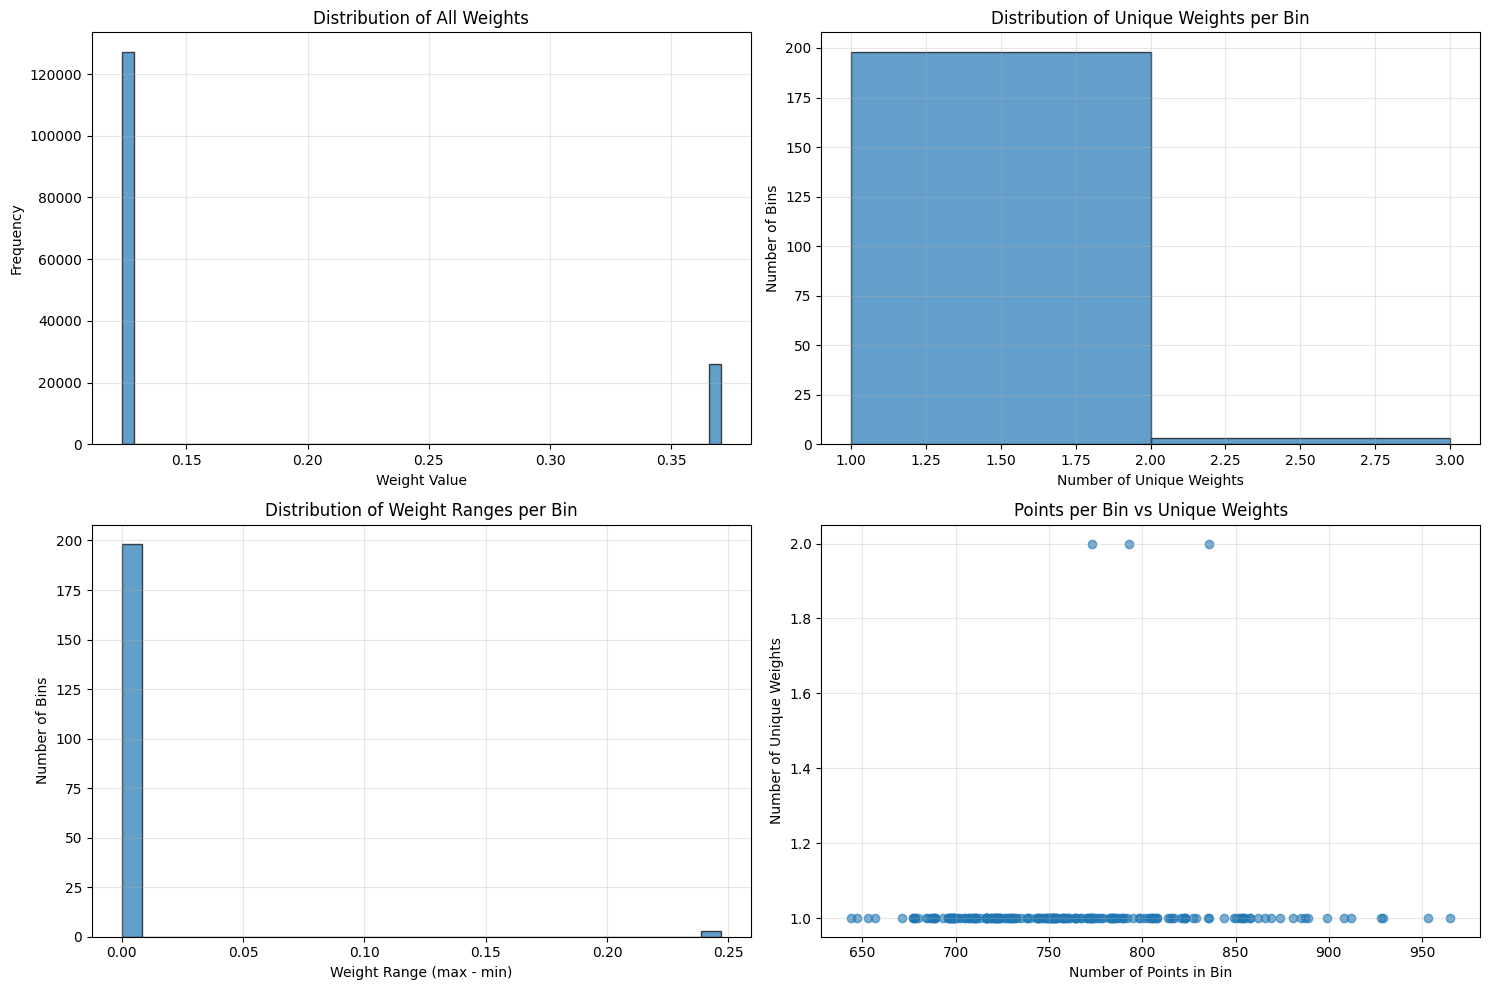


EXAMPLE BINS WITH WEIGHTS

Bin 0:
  Points: 773
  Unique weights: 2
  Weight values: [0.1234473  0.37034191]
  Range: [0.123447, 0.370342]

Bin 1:
  Points: 821
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 2:
  Points: 852
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 3:
  Points: 881
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 4:
  Points: 908
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 5:
  Points: 866
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 6:
  Points: 823
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 7:
  Points: 823
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 8:
  Points: 854
  Unique weights: 1
  Weight values: [0.37034191]
  Range: [0.370342, 0.370342]

Bin 9:
  Points: 912
  Unique weights: 1
  

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

def analyze_weights(filename="weights_values_binning.txt"):
    """Analyze the weights from the binning function"""

    # Get the full path to the file in home directory
    home_dir = os.path.expanduser("~")
    full_path = os.path.join(home_dir, filename)

    print(f"Analyzing file: {full_path}")

    # Load the weights data
    try:
        with open(full_path, 'r') as f:
            content = f.read()

        # Parse the weights (assuming they're printed as lists)
        weights_lines = []
        for line in content.strip().split('\n'):
            if 'DEBUG: weight' in line:
                # Extract the weights array from the line
                weights_str = line.split('DEBUG: weight')[1].strip()
                # Convert string representation to actual array
                weights = eval(weights_str)
                weights_lines.append(weights)

        print(f"Loaded {len(weights_lines)} bins with weights")

        if not weights_lines:
            print("No weights found in file!")
            return

        # Analyze weights
        all_weights = []
        bin_stats = []

        for i, weights in enumerate(weights_lines):
            if len(weights) > 0:
                weights = np.array(weights)
                all_weights.extend(weights)

                unique_weights = np.unique(weights)
                bin_stats.append({
                    'bin_idx': i,
                    'n_points': len(weights),
                    'unique_weights': len(unique_weights),
                    'min_weight': np.min(weights),
                    'max_weight': np.max(weights),
                    'mean_weight': np.mean(weights),
                    'std_weight': np.std(weights),
                    'unique_values': unique_weights
                })

        all_weights = np.array(all_weights)

        # Print statistics
        print("\n" + "="*60)
        print("WEIGHT ANALYSIS STATISTICS")
        print("="*60)

        print(f"Total weights across all bins: {len(all_weights)}")
        print(f"Unique weight values: {len(np.unique(all_weights))}")
        print(f"Weight range: [{np.min(all_weights):.6f}, {np.max(all_weights):.6f}]")
        print(f"Mean weight: {np.mean(all_weights):.6f}")
        print(f"Std weight: {np.std(all_weights):.6f}")

        print(f"\nPer-bin statistics:")
        print(f"Bins with data: {len(bin_stats)}")
        print(f"Average points per bin: {np.mean([b['n_points'] for b in bin_stats]):.1f}")
        print(f"Average unique weights per bin: {np.mean([b['unique_weights'] for b in bin_stats]):.1f}")

        # Find bins with multiple unique weights
        multi_weight_bins = [b for b in bin_stats if b['unique_weights'] > 1]
        print(f"Bins with multiple unique weights: {len(multi_weight_bins)}")

        if multi_weight_bins:
            print(f"\nFirst few bins with multiple weights:")
            for b in multi_weight_bins[:5]:
                print(f"  Bin {b['bin_idx']}: {b['n_points']} points, {b['unique_weights']} unique weights")
                print(f"    Values: {b['unique_values']}")
                print(f"    Range: [{b['min_weight']:.6f}, {b['max_weight']:.6f}]")

        # Create plots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: Histogram of all weights
        axes[0,0].hist(all_weights, bins=50, alpha=0.7, edgecolor='black')
        axes[0,0].set_title("Distribution of All Weights")
        axes[0,0].set_xlabel("Weight Value")
        axes[0,0].set_ylabel("Frequency")
        axes[0,0].grid(True, alpha=0.3)

        # Plot 2: Number of unique weights per bin
        unique_counts = [b['unique_weights'] for b in bin_stats]
        axes[0,1].hist(unique_counts, bins=range(1, max(unique_counts)+2), alpha=0.7, edgecolor='black')
        axes[0,1].set_title("Distribution of Unique Weights per Bin")
        axes[0,1].set_xlabel("Number of Unique Weights")
        axes[0,1].set_ylabel("Number of Bins")
        axes[0,1].grid(True, alpha=0.3)

        # Plot 3: Weight range per bin
        weight_ranges = [b['max_weight'] - b['min_weight'] for b in bin_stats]
        axes[1,0].hist(weight_ranges, bins=30, alpha=0.7, edgecolor='black')
        axes[1,0].set_title("Distribution of Weight Ranges per Bin")
        axes[1,0].set_xlabel("Weight Range (max - min)")
        axes[1,0].set_ylabel("Number of Bins")
        axes[1,0].grid(True, alpha=0.3)

        # Plot 4: Points per bin vs unique weights
        n_points = [b['n_points'] for b in bin_stats]
        unique_weights = [b['unique_weights'] for b in bin_stats]
        axes[1,1].scatter(n_points, unique_weights, alpha=0.6)
        axes[1,1].set_title("Points per Bin vs Unique Weights")
        axes[1,1].set_xlabel("Number of Points in Bin")
        axes[1,1].set_ylabel("Number of Unique Weights")
        axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Show some example bins with their weights
        print(f"\n" + "="*60)
        print("EXAMPLE BINS WITH WEIGHTS")
        print("="*60)

        for i, b in enumerate(bin_stats[:10]):  # Show first 10 bins
            print(f"\nBin {b['bin_idx']}:")
            print(f"  Points: {b['n_points']}")
            print(f"  Unique weights: {b['unique_weights']}")
            print(f"  Weight values: {b['unique_values']}")
            print(f"  Range: [{b['min_weight']:.6f}, {b['max_weight']:.6f}]")

        return bin_stats, all_weights

    except FileNotFoundError:
        print(f"File not found at {full_path}")
        return None, None
    except Exception as e:
        print(f"Error loading file: {e}")
        return None, None

# Run the analysis
bin_stats, all_weights = analyze_weights("weights_values_binning.txt")

In [12]:
def split_and_calculate_weights(time, flux, gap_width=0.75):
    """Split the time and flux whenever there is a gap in the time array.
    For each segment, calculate the scatter of the flux values and return
    an array of weights where the higher scatter values have lower weights.

    Args:
        time: 1D array of time values
        flux: 1D array of flux values
        period: The period of the event (in days)
        num_bins: The number of intervals to divide the time axis into
        t_min: The inclusive leftmost value to consider on the time axis
        t_max: The exclusive rightmost value to consider on the time axis
        gap_width: Minimum gap size (in time units) for a split

    Returns:
        weights: Array of weights for each data point
    """
    import numpy as np
    from light_curve_util.keplersplinev2 import split

    # Split the data into segments based on gaps
    split_times, split_fluxes = split(time, flux, gap_width)

    # Initialize weights array
    weights = np.ones(len(time))

    # Calculate scatter for each segment
    segment_scatters = []
    for seg_flux in split_fluxes:
        if len(seg_flux) > 1:
            segment_scatters.append(np.std(seg_flux))
        else:
            segment_scatters.append(0.0)  # Single points get scatter 0

    # Calculate weights based on inverse scatter
    if len(segment_scatters) > 1 and np.max(segment_scatters) > 0:
        # Normalize scatters to [0, 1] range
        max_scatter = np.max(segment_scatters)
        normalized_scatters = np.array(segment_scatters) / max_scatter

        # Weight is inversely proportional to normalized scatter
        # Add small value to avoid division by zero
        segment_weights = 1.0 / (normalized_scatters + 0.1)

        # Apply weights to each segment
        start_idx = 0
        for i, (seg_time, seg_flux) in enumerate(zip(split_times, split_fluxes)):
            end_idx = start_idx + len(seg_time)
            weights[start_idx:end_idx] = segment_weights[i]
            start_idx = end_idx

    return weights

In [13]:
1e-2

0.01